In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> src/pipelines/04_eda_annot_gt_cycle/01_ukdale_gt_cycle_eda.py.
> Edit the source and re-export; do not edit the exported notebook by hand.

# GT-cycle EDA: can a user mark carry a device profile?

The question this notebook exists for: **if a user merely marks "the
machine ran roughly here", can we (a) tell which device it was and (b)
turn that mark into a profile that predicts the device's cycles from the
aggregate alone?** Everything is inspected by eye first, then measured.

Data: UK-DALE house 1 gold layer, native cadence (statement sections
0, 5-8). Submeter channels are the measured ground truth and do the
scoring; every profile feature is derived from the **aggregate only**.
The button-press channel is not used as ground truth anywhere here (its
H02 verdict stands: near-chance alignment with appliance onsets). All
numbers are provisional until margins freeze; nothing below is a gate.

In [ ]:
# Headless rendering (export runs without a display) + shared baseline
# lib. baseline_lib lives with the 00_baseline experiment; the path is
# resolved relative to this file so the notebook stays relocatable.
import sys
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
_here = Path(__file__).resolve()
sys.path.insert(0, str(_here.parents[2] / "experiments" / "00_baseline"))
import baseline_lib as bl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# --- Notebook parameters (provisional, stated up front) ---------------
# Timestamps: int64 UTC microseconds (us); durations in seconds; power W.
# Cycle rules per device class (thr from the quarantined thresholds.json;
# dwell and merge are this EDA's verdict, not frozen contract values):
#   program appliances: long dwell + long merge (one cycle = one block)
#   burst appliances:   raw short episodes (the cycle rule is meaningless)
#   fridge: duty-cycling compressor, excluded from user-cycle GT.
cfg = {
    "dataset": "ukdale",
    "house": "house_1",
    "split_us": int(pd.Timestamp("2013-10-01", tz="UTC").value / 1000),
    "cycle_rules": {
        "washing_machine": dict(dwell=600.0, merge=600.0),
        "dishwasher": dict(dwell=600.0, merge=600.0),
        "kettle": dict(dwell=30.0, merge=60.0),
        "microwave": dict(dwell=30.0, merge=60.0),
        "fridge": dict(dwell=30.0, merge=12.0),
    },
    "cycle_like_s": 600.0,  # cycle-like for program appliances: >= 10 min
    "cycle_like_wh": 100.0,  # ... and >= 100 Wh (a real wash, not a blip)
    # Aggregate activation runs (part D): the detection vocabulary that a
    # mark-derived profile has to live in.
    "smooth_s": 30.0,  # 5-sample centered mean at the 6 s cadence
    "hys_on_w": 500.0,  # run starts when smoothed mains crosses this
    "hys_off_w": 200.0,  # run ends after 3 samples consecutively below
    "base_win_s": 60.0,  # pre-run baseline window for the dP estimate
    # Mark-to-profile features and the detection chain (part F):
    "det_thr_frac": 0.6,  # qualifying activation: dP >= 0.6 x profile dP
    "det_dur_lo": 0.5,  # candidate cycle dur >= 0.5 x profile dur
    "det_dur_hi": 2.0,  # candidate cycle dur <= 2.0 x profile dur
    "chain_gap_lo_s": 300.0,  # chaining gap clamp (lower bound)
    "chain_gap_hi_s": 1800.0,  # chaining gap clamp (upper bound)
    "burst_dur_hi_s": 600.0,  # burst device = a single run up to 10 min
    "ov_min_s": 60.0,  # cycle match: >= 60 s overlap with submeter GT
    "ov_frac": 0.3,  # ... or >= 30% of the GT cycle, whichever smaller
    "seed": 3,
}

In [ ]:
# presentation: parameters table
mo.md(
    "## Parameters used in this EDA\n\n"
    + bl.md_table(["parameter", "value"], [[k, v] for k, v in cfg.items()])
)

## Parameters used in this EDA

| parameter | value |
|---|---|
| dataset | ukdale |
| house | house_1 |
| split_us | 1380585600000000 |
| cycle_rules | {'washing_machine': {'dwell': 600.0, 'merge': 600.0}, 'dishwasher': {'dwell': 600.0, 'merge': 600.0}, 'kettle': {'dwell': 30.0, 'merge': 60.0}, 'microwave': {'dwell': 30.0, 'merge': 60.0}, 'fridge': {'dwell': 30.0, 'merge': 12.0}} |
| cycle_like_s | 600.0 |
| cycle_like_wh | 100.0 |
| smooth_s | 30.0 |
| hys_on_w | 500.0 |
| hys_off_w | 200.0 |
| base_win_s | 60.0 |
| det_thr_frac | 0.6 |
| det_dur_lo | 0.5 |
| det_dur_hi | 2.0 |
| chain_gap_lo_s | 300.0 |
| chain_gap_hi_s | 1800.0 |
| burst_dur_hi_s | 600.0 |
| ov_min_s | 60.0 |
| ov_frac | 0.3 |
| seed | 3 |

In [ ]:
# --- Load gold channels once (computation) -----------------------------
# mains = aggregate (the only detector-side signal in part F); the
# canonical channels are submeters - measured ground truth, never
# detector input. thr comes from the quarantined thresholds.json.
import json

mains_df = bl.load_series(bl.gold_file(cfg["dataset"], cfg["house"], "mains"))
chans = {
    c: bl.load_series(bl.gold_file(cfg["dataset"], cfg["house"], c))
    for c in cfg["cycle_rules"]
}
with open(f"{bl.ROOT}/data/gold/thresholds.json") as fh:
    _thr_all = json.load(fh)
thr = {
    c: float(_thr_all[cfg["dataset"]][cfg["house"]][c]["thr_on_W"])
    for c in cfg["cycle_rules"]
}

In [ ]:
# --- Data health (computation: measured, not assumed) ------------------
def _modal_dt_s(ts_us):
    d = np.diff(ts_us) / 1e6
    d = d[(d > 0) & (d < 60)]
    if d.size == 0:
        return float("nan")
    vals, counts = np.unique(np.round(d, 1), return_counts=True)
    return float(vals[np.argmax(counts)])

_t0, _t1 = int(mains_df["ts_us"].iloc[0]), int(mains_df["ts_us"].iloc[-1])
_recs = []
for _name, _df in [("mains", mains_df)] + [(c, chans[c]) for c in sorted(chans)]:
    _ts = _df["ts_us"].to_numpy(np.int64)
    _dt = _modal_dt_s(_ts)
    _fill = _ts.size / max((_ts[-1] - _ts[0]) / (_dt * 1e6), 1.0)
    _recs.append(
        {"channel": _name, "rows": int(_ts.size), "modal_dt_s": _dt, "fill": _fill}
    )
health = {"t0_us": _t0, "t1_us": _t1, "channels": _recs}

In [ ]:
# presentation: health table + span
_t0, _t1 = health["t0_us"], health["t1_us"]
_rows = [
    [c["channel"], f"{c['rows']:,}", f"{c['modal_dt_s']:.1f}", f"{100 * c['fill']:.0f}%"]
    for c in health["channels"]
]
mo.md(
    "## Data health (measured)\n\n"
    + bl.md_table(["channel", "rows", "modal dt (s)", "modal-interval fill"], _rows)
    + f"\n\nSpan: {(_t1 - _t0) / 86400e6:.2f} days "
    + f"({pd.to_datetime(_t0, unit='us'):%Y-%m-%d} to {pd.to_datetime(_t1, unit='us'):%Y-%m-%d}, UTC)."
)

## Data health (measured)

| channel | rows | modal dt (s) | modal-interval fill |
|---|---|---|---|
| mains | 21,837,636 | 6.0 | 93% |
| dishwasher | 19,819,392 | 6.0 | 85% |
| fridge | 19,381,298 | 6.0 | 84% |
| kettle | 18,881,051 | 6.0 | 81% |
| microwave | 19,406,625 | 6.0 | 85% |
| washing_machine | 19,555,935 | 6.0 | 83% |

Span: 1628.79 days (2012-11-09 to 2017-04-26, UTC).

## Part A - look at the raw channels first

Before trusting any rule, look at what a washing-machine cycle actually
looks like on both sides: the submeter channel (the label source) and
the aggregate (the only deployment-time signal). Three days, chosen
without looking at any rule output: the day with the most washing-machine
ON time, a median-activity day, and a quiet one.

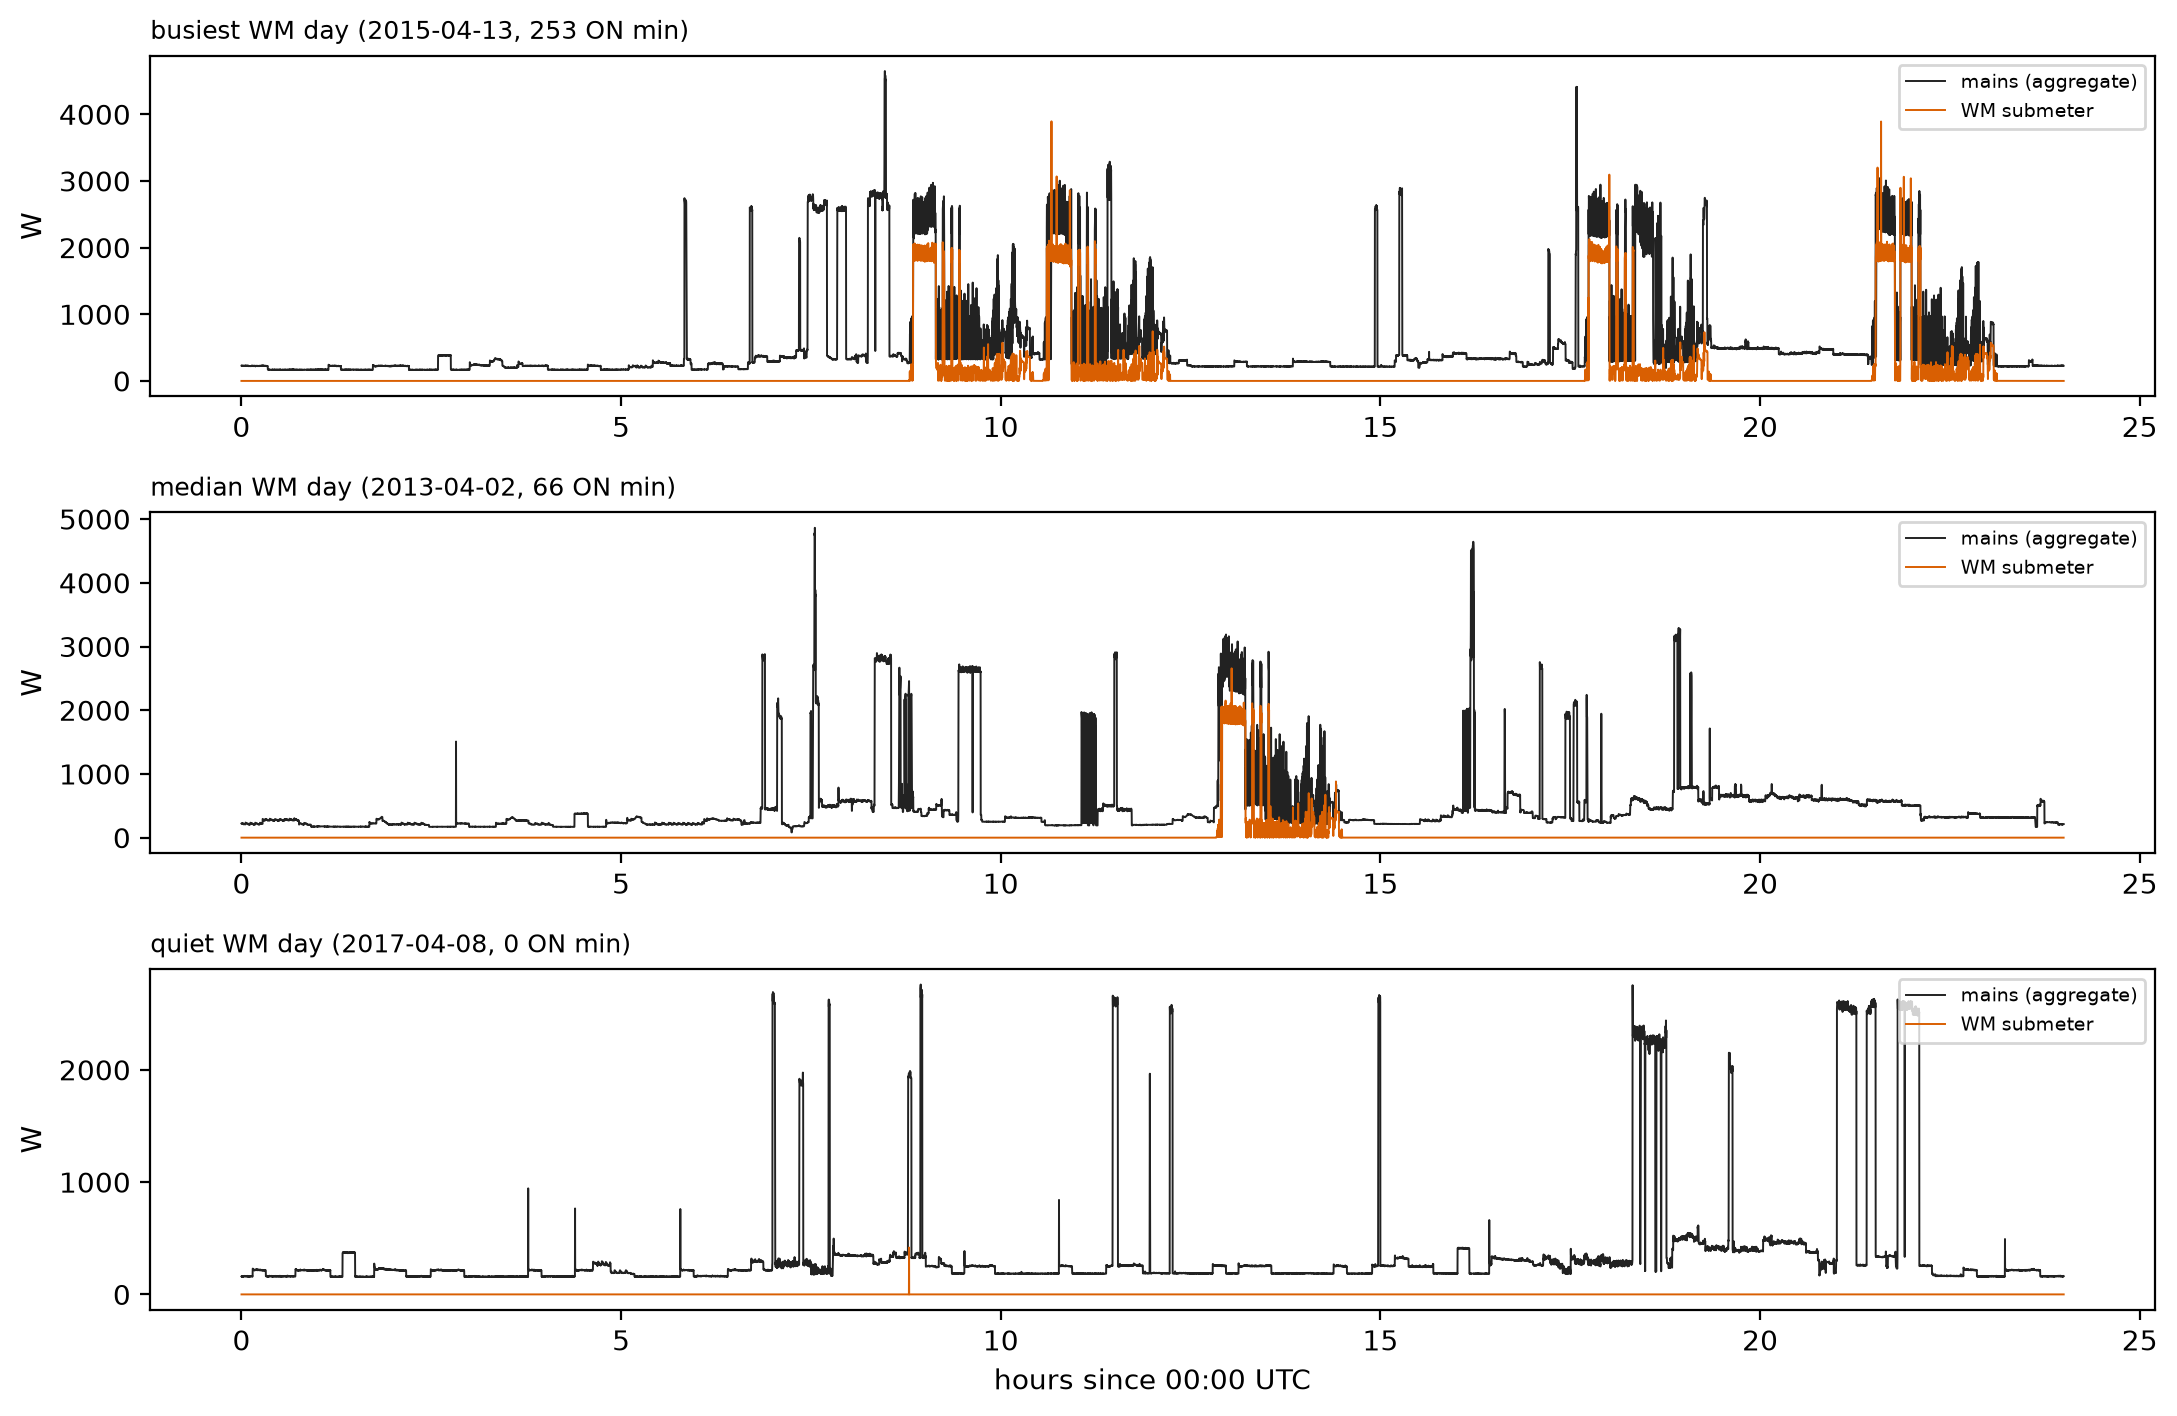

In [ ]:
# --- Sample days + raw overlay figure (computation + figure) -----------
# Rank UTC days by washing-machine ON minutes (minutes above 50 W on the
# submeter channel); pick busiest / median / quiet. Slice raw rows, plot
# mains vs the WM submeter - no resampling anywhere.
_wm = chans["washing_machine"]
_wm_ts = _wm["ts_us"].to_numpy(np.int64)
_wm_w = _wm["w"].to_numpy(float)
_days = (_wm_ts // 86_400_000_000).astype(np.int64)
_on_min = {}
for _d in np.unique(_days):
    _sel = _days == _d
    _on_min[int(_d)] = float(np.sum(_wm_w[_sel] > 50.0) * 6.0 / 60.0)
_ranked = sorted(_on_min, key=_on_min.get, reverse=True)
_active = [d for d in _ranked if _on_min[d] > 0]
day_info = {
    "busiest": _active[0],
    "median": _active[len(_active) // 2],
    "quiet": _active[-1],
    "on_min": _on_min,
}

_m_ts = mains_df["ts_us"].to_numpy(np.int64)
_m_w = mains_df["w"].to_numpy(float)
_names = ("busiest", "median", "quiet")
fig_days, _axes = plt.subplots(3, 1, figsize=(11, 7.2), sharex=False)
for _ax, _name in zip(_axes, _names):
    _d = day_info[_name]
    _lo, _hi = _d * 86_400_000_000, (_d + 1) * 86_400_000_000
    _i0, _i1 = np.searchsorted(_m_ts, _lo), np.searchsorted(_m_ts, _hi)
    _j0, _j1 = np.searchsorted(_wm_ts, _lo), np.searchsorted(_wm_ts, _hi)
    _ax.plot((_m_ts[_i0:_i1] - _lo) / 3.6e9, _m_w[_i0:_i1], color="#222222", lw=0.7, label="mains (aggregate)")
    _ax.plot((_wm_ts[_j0:_j1] - _lo) / 3.6e9, _wm_w[_j0:_j1], color="#d95f02", lw=0.7, label="WM submeter")
    _ax.set_ylabel("W")
    _ax.set_title(
        f"{_name} WM day ({pd.to_datetime(_lo, unit='us'):%Y-%m-%d}, {_on_min[_d]:.0f} ON min)",
        fontsize=9,
        loc="left",
    )
    _ax.legend(fontsize=7, loc="upper right")
_axes[-1].set_xlabel("hours since 00:00 UTC")
fig_days.tight_layout()
fig_days  # noqa: B018  (render figure as cell output)

Reading the three days. The washing machine is a **multi-activation
program**: several separated power blocks (heater, pump, spin) spanning
one to two hours, with quiet valleys inside the cycle. On the aggregate
those blocks mix with everything else in the house - which is exactly
the ambiguity part F quantifies.

## Part B - the episode rule, grid-searched and verified by eye

The gold ON-runs come from a threshold rule plus two knobs: min_dwell
(drop episodes shorter than this) and merge_gap (glue ON-runs separated
by at most this). The current gold rule (30 s dwell, 12 s merge) was
built for episode-level GT; the question is what it does to *cycles*.
The grid varies all three knobs on the washing-machine channel; every
cell is computed, none assumed.

In [ ]:
# --- Rule grid on the washing machine (computation) --------------------
# For each (thr, dwell, merge): all episodes, and the cycle-like subset
# (>= 10 min and >= 100 Wh). "ON-energy share" = cycle-like energy over
# all episode energy at that threshold - how much of the machine's work
# the cycle definition actually captures.
_wm = chans["washing_machine"]
grid_rows = []
for _thr in (50.0, 90.0, 150.0):
    _ep = bl.build_episodes(_wm, _thr, 30.0, 12.0, 60.0)
    _tot_wh = float(_ep["energy_wh"].sum())
    for _dwell in (30.0, 600.0):
        for _merge in (12.0, 300.0, 1800.0):
            _e = bl.build_episodes(_wm, _thr, _dwell, _merge, 60.0)
            _cl = _e[(_e["dur_s"] >= 600.0) & (_e["energy_wh"] >= 100.0)]
            grid_rows.append(
                {
                    "thr_W": _thr,
                    "dwell_s": _dwell,
                    "merge_s": _merge,
                    "n_ep": int(len(_e)),
                    "n_cycle": int(len(_cl)),
                    "dur_p50_min": float(_cl["dur_s"].median() / 60.0) if len(_cl) else float("nan"),
                    "on_share": float(_cl["energy_wh"].sum() / _tot_wh) if _tot_wh else 0.0,
                }
            )
grid_df = pd.DataFrame(grid_rows)

In [ ]:
# presentation: rule grid
_rows = [
    [
        f"{r.thr_W:.0f}",
        f"{r.dwell_s:.0f}",
        f"{r.merge_s:.0f}",
        f"{r.n_ep:,}",
        f"{r.n_cycle:,}",
        f"{r.dur_p50_min:.0f}",
        f"{100 * r.on_share:.0f}%",
    ]
    for r in grid_df.itertuples()
]
mo.md(
    "### Washing-machine rule grid\n\n"
    + bl.md_table(
        ["thr (W)", "dwell (s)", "merge (s)", "episodes", "cycle-like", "cycle p50 dur (min)", "ON-energy share"],
        _rows,
    )
    + "\n\nReading it. **merge is the dominant lever**: at the gold merge "
    "of 12 s the machine shatters into tens of thousands of activation "
    "fragments; anywhere from 300 s to 1800 s the cycle count stabilizes "
    "and the median duration lands near the physically expected 1-2 h. "
    "The threshold is a second-order knob between 50 W and 150 W. The "
    "gold episode rule is not broken code - it was built to answer a "
    "different question (episode-level GT) and does that well; the "
    "cycle question needs its own label definition."
)

### Washing-machine rule grid

| thr (W) | dwell (s) | merge (s) | episodes | cycle-like | cycle p50 dur (min) | ON-energy share |
|---|---|---|---|---|---|---|
| 50 | 30 | 12 | 32,530 | 1,171 | 17 | 67% |
| 50 | 30 | 300 | 1,437 | 1,317 | 91 | 104% |
| 50 | 30 | 1800 | 1,337 | 1,254 | 93 | 104% |
| 50 | 600 | 12 | 1,175 | 1,171 | 17 | 67% |
| 50 | 600 | 300 | 1,417 | 1,317 | 91 | 104% |
| 50 | 600 | 1800 | 1,331 | 1,254 | 93 | 104% |
| 90 | 30 | 12 | 25,883 | 1,150 | 17 | 68% |
| 90 | 30 | 300 | 1,744 | 1,307 | 90 | 104% |
| 90 | 30 | 1800 | 1,336 | 1,246 | 92 | 105% |
| 90 | 600 | 12 | 1,155 | 1,150 | 17 | 68% |
| 90 | 600 | 300 | 1,612 | 1,307 | 90 | 104% |
| 90 | 600 | 1800 | 1,328 | 1,246 | 92 | 105% |
| 150 | 30 | 12 | 20,614 | 1,132 | 17 | 69% |
| 150 | 30 | 300 | 2,656 | 1,264 | 86 | 101% |
| 150 | 30 | 1800 | 1,352 | 1,234 | 89 | 105% |
| 150 | 600 | 12 | 1,135 | 1,132 | 17 | 69% |
| 150 | 600 | 300 | 1,535 | 1,264 | 86 | 101% |
| 150 | 600 | 1800 | 1,335 | 1,234 | 89 | 105% |

Reading it. **merge is the dominant lever**: at the gold merge of 12 s the machine shatters into tens of thousands of activation fragments; anywhere from 300 s to 1800 s the cycle count stabilizes and the median duration lands near the physically expected 1-2 h. The threshold is a second-order knob between 50 W and 150 W. The gold episode rule is not broken code - it was built to answer a different question (episode-level GT) and does that well; the cycle question needs its own label definition.

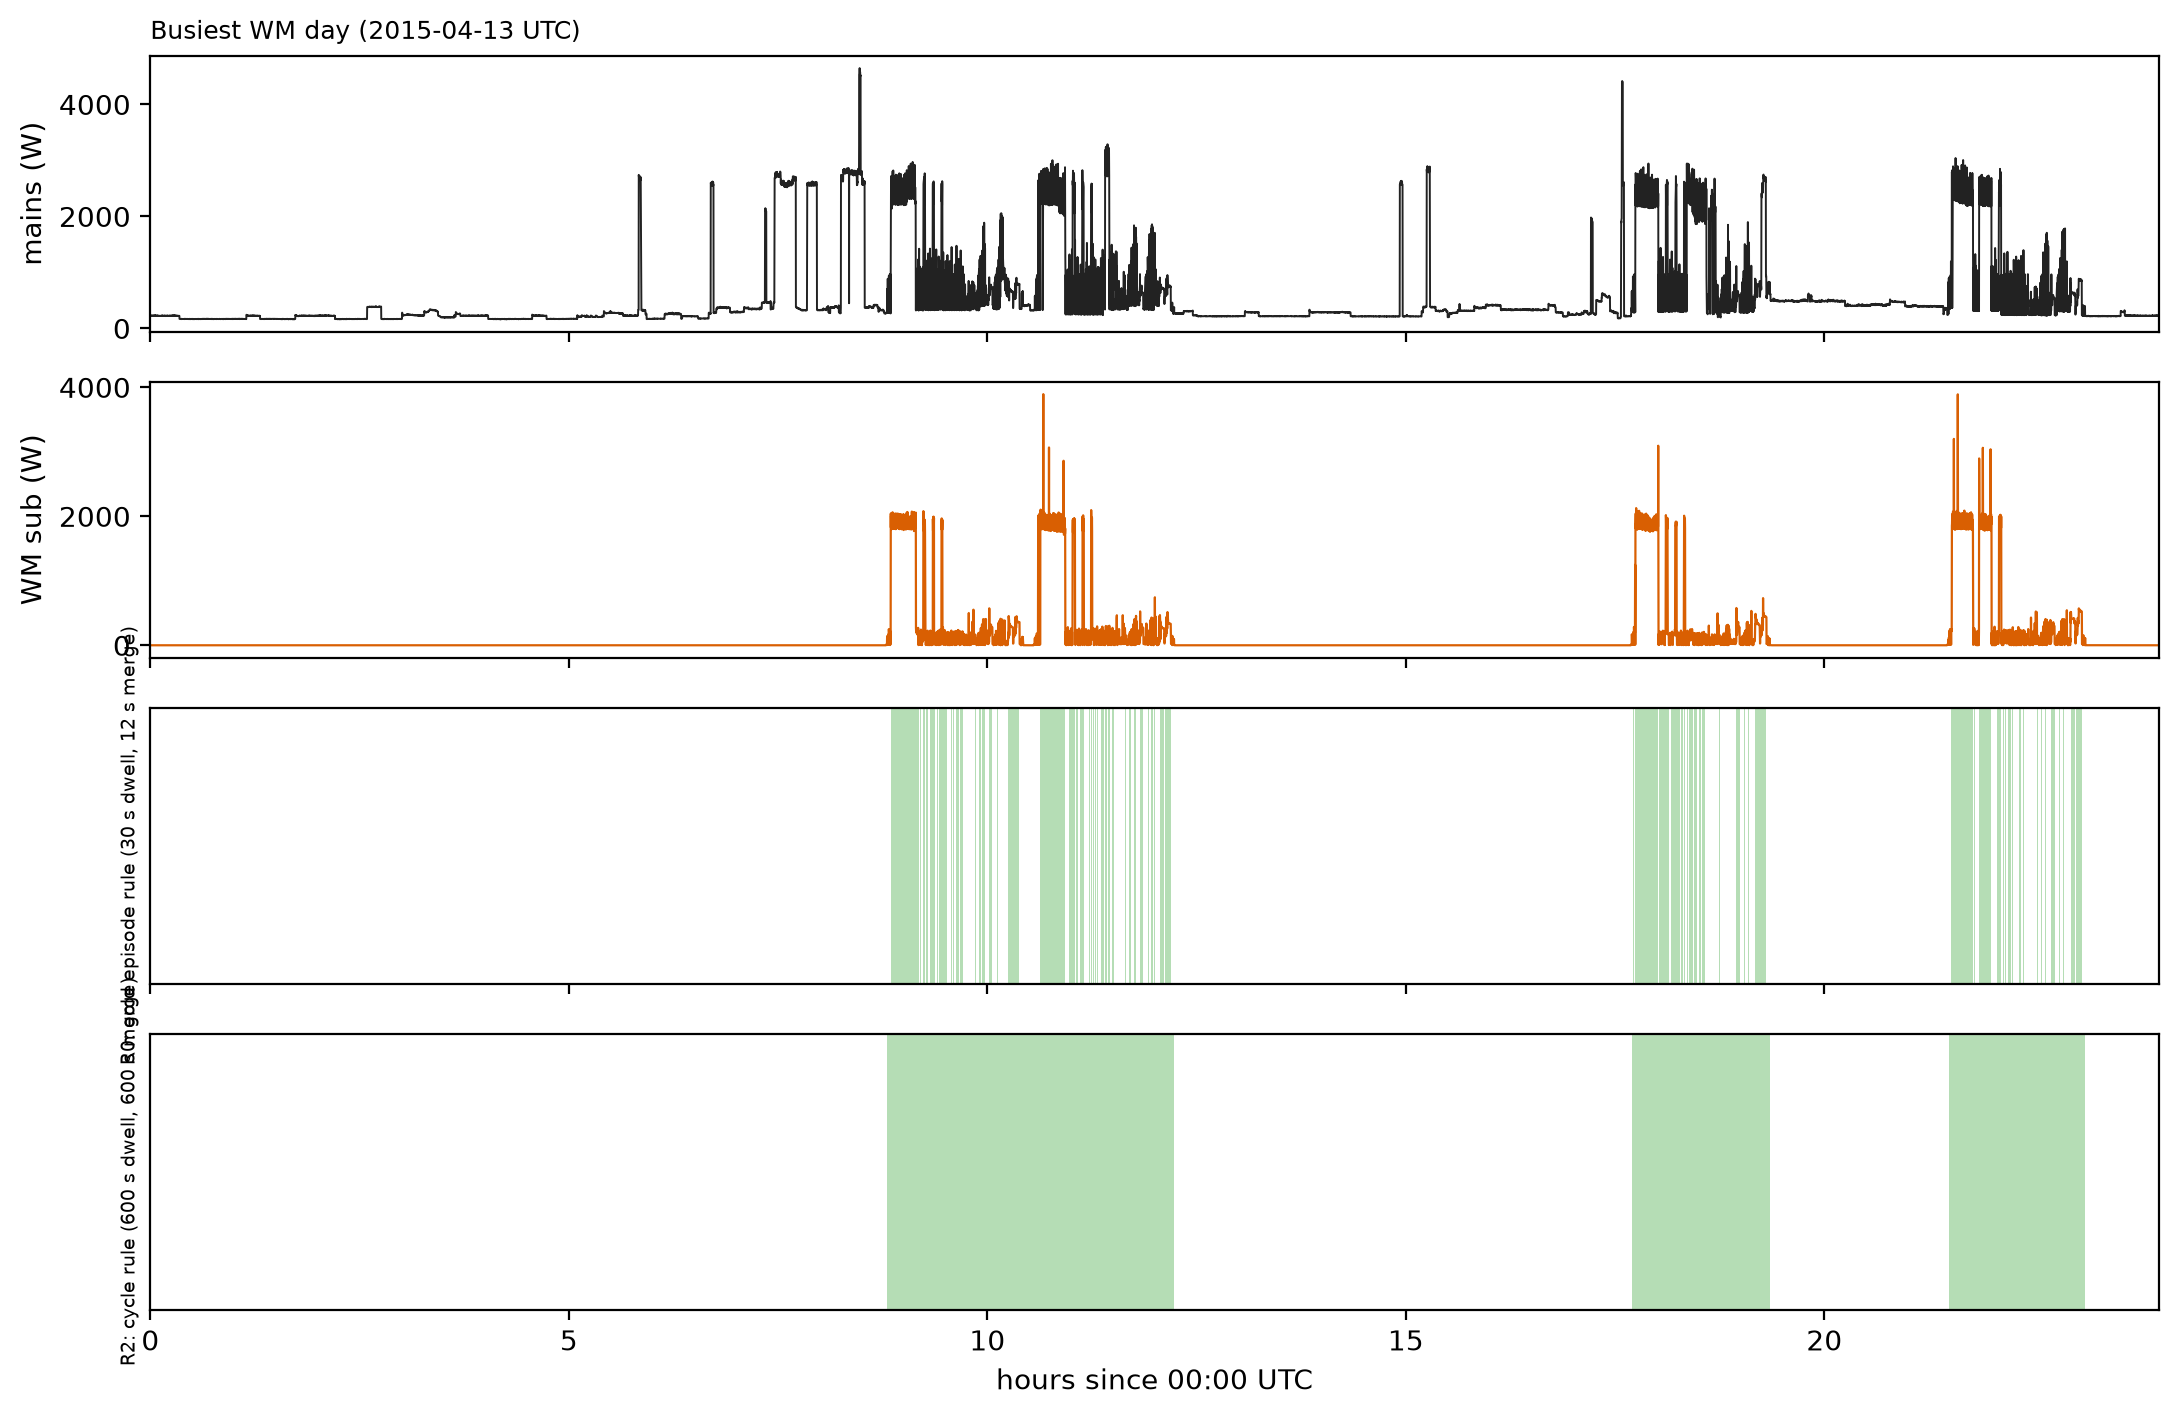

In [ ]:
# --- Visual rule verification on the busiest WM day (computation+fig) --
# Same day, two rules: R0 = gold episode rule (90 W, 30 s, 12 s),
# R2 = cycle rule (90 W, 600 s, 600 s). Strips top to bottom: mains,
# submeter, R0 spans, R2 spans. Episodes are computed on the full
# channel, then sliced to the day for drawing.
_d = day_info["busiest"]
_lo, _hi = _d * 86_400_000_000, (_d + 1) * 86_400_000_000
_m_ts = mains_df["ts_us"].to_numpy(np.int64)
_m_w = mains_df["w"].to_numpy(float)
_wm = chans["washing_machine"]
_wm_ts = _wm["ts_us"].to_numpy(np.int64)
_wm_w = _wm["w"].to_numpy(float)
_r0 = bl.build_episodes(_wm, 90.0, 30.0, 12.0, 60.0)
_r2 = bl.build_episodes(_wm, 90.0, 600.0, 600.0, 60.0)
fig_ov, _axes = plt.subplots(4, 1, figsize=(11, 7.2), sharex=True)
_i0, _i1 = np.searchsorted(_m_ts, _lo), np.searchsorted(_m_ts, _hi)
_axes[0].plot((_m_ts[_i0:_i1] - _lo) / 3.6e9, _m_w[_i0:_i1], color="#222222", lw=0.7)
_axes[0].set_ylabel("mains (W)")
_axes[0].set_title(f"Busiest WM day ({pd.to_datetime(_lo, unit='us'):%Y-%m-%d} UTC)", fontsize=9, loc="left")
_j0, _j1 = np.searchsorted(_wm_ts, _lo), np.searchsorted(_wm_ts, _hi)
_axes[1].plot((_wm_ts[_j0:_j1] - _lo) / 3.6e9, _wm_w[_j0:_j1], color="#d95f02", lw=0.8)
_axes[1].set_ylabel("WM sub (W)")
for _ax, _ep, _label in (
    (_axes[2], _r0, "R0: gold episode rule (30 s dwell, 12 s merge)"),
    (_axes[3], _r2, "R2: cycle rule (600 s dwell, 600 s merge)"),
):
    _sel = _ep[(_ep["t_on_us"] < _hi) & (_ep["t_off_us"] > _lo)]
    for _r in _sel.itertuples():
        _ax.axvspan((_r.t_on_us - _lo) / 3.6e9, (_r.t_off_us - _lo) / 3.6e9, color="#2ca02c", alpha=0.35, lw=0)
    _ax.set_ylabel(_label, fontsize=7)
    _ax.set_yticks([])
_axes[-1].set_xlabel("hours since 00:00 UTC")
_axes[0].set_xlim(0, 24)
fig_ov.tight_layout()
ov_info = {
    "r0_n_day": int(((_r0["t_on_us"] < _hi) & (_r0["t_off_us"] > _lo)).sum()),
    "r2_n_day": int(((_r2["t_on_us"] < _hi) & (_r2["t_off_us"] > _lo)).sum()),
}
fig_ov  # noqa: B018  (render figure as cell output)

The picture is the argument. Under the gold episode rule the machine's
individual activations become separate "episodes" (green slivers), none
of which is a wash; under the cycle rule the same activations collapse
into a handful of hour-scale blocks that line up with what a human
would call "the machine ran". Verdict: **the episode rule is not broken
- it is the wrong label for cycles**, and cycles need dwell/merge at
the program scale. This EDA uses 600 s / 600 s for the two program
appliances throughout; the grid shows the choice is not knife-edge.

## Part C - one rule per device class, not one rule for all

Program appliances (washing machine, dishwasher) need the cycle rule.
Burst appliances (kettle, microwave) are single activations - a "cycle"
is one boil or one cook, and raw short episodes are already the right
granularity; glueing bursts would only distort durations. The fridge is
duty cycling: thousands of compressor runs, none of them a user event.
The table measures each device under its class rule.

In [ ]:
# --- Per-device cycle stats under class rules (computation) ------------
# Program devices: cycle-like = >= 10 min and >= 100 Wh under (600, 600).
# Burst devices: all episodes under (30, 60). Fridge: (30, 12) shows the
# compressor run count - kept for the verdict, excluded from user GT.
devrules = []
for _dev, _rule in cfg["cycle_rules"].items():
    _s = chans[_dev]
    _t = thr[_dev]
    _e = bl.build_episodes(_s, _t, _rule["dwell"], _rule["merge"], 60.0)
    if _dev in ("washing_machine", "dishwasher"):
        _cl = _e[(_e["dur_s"] >= cfg["cycle_like_s"]) & (_e["energy_wh"] >= 100.0)]
        _cls, _n = "program", int(len(_cl))
        _p50 = float(_cl["dur_s"].median() / 60.0) if len(_cl) else float("nan")
    elif _dev == "fridge":
        _cls, _n, _p50 = "duty", int(len(_e)), float(_e["dur_s"].median() / 60.0)
    else:
        _cls, _n, _p50 = "burst", int(len(_e)), float(_e["dur_s"].median() / 60.0)
    devrules.append({"device": _dev, "thr_W": _t, "n": _n, "dur_p50_min": _p50, "class": _cls})

In [ ]:
# presentation: per-device table + class verdicts
_rows = [
    [r["device"], f"{r['thr_W']:.1f}", f"{r['n']:,}", f"{r['dur_p50_min']:.1f}", r["class"]]
    for r in devrules
]
mo.md(
    "### Device classes under their rules\n\n"
    + bl.md_table(["device", "thr (W)", "cycles / episodes", "p50 dur (min)", "class"], _rows)
    + "\n\nVerdicts. **washing machine / dishwasher**: hour-scale multi-"
    "activation programs - cycle GT = (thr, 600 s, 600 s) blocks. "
    "**kettle / microwave**: minute-scale bursts; keep raw episodes - "
    "the cycle rule is meaningless for them (it glues unrelated boils "
    "into fake marathons). **fridge**: compressor duty cycling with no "
    "user intent - excluded from user-cycle GT entirely. This three-way "
    "split is a finding, not a taste: one global rule cannot serve all "
    "three classes at once."
)

### Device classes under their rules

| device | thr (W) | cycles / episodes | p50 dur (min) | class |
|---|---|---|---|---|
| washing_machine | 90.0 | 1,294 | 91.0 | program |
| dishwasher | 60.5 | 679 | 85.8 | program |
| kettle | 1173.0 | 6,897 | 1.8 | burst |
| microwave | 762.0 | 5,047 | 1.0 | burst |
| fridge | 44.5 | 39,666 | 24.6 | duty |

Verdicts. **washing machine / dishwasher**: hour-scale multi-activation programs - cycle GT = (thr, 600 s, 600 s) blocks. **kettle / microwave**: minute-scale bursts; keep raw episodes - the cycle rule is meaningless for them (it glues unrelated boils into fake marathons). **fridge**: compressor duty cycling with no user intent - excluded from user-cycle GT entirely. This three-way split is a finding, not a taste: one global rule cannot serve all three classes at once.

## Part D - what the aggregate can see (activation runs)

Deployment has no submeters, so the only detection vocabulary is what
the aggregate shows: **activation runs** - stretches where the smoothed
aggregate sits above a hysteresis band (on above 500 W, off below
200 W). Every run gets a dP = peak of the smoothed run minus the median
of the 60 s before it. These runs are the atoms any mark-derived
profile must be built from and matched against.

In [ ]:
# --- Activation runs with hysteresis (computation) ---------------------
# Smooth the aggregate with a 5-sample (30 s) centered mean; a run
# starts on a rise through hys_on_w and ends after 3 consecutive
# samples below hys_off_w. dP per run: peak(smooth inside run) minus
# median(60 s pre-start).
_m_ts = mains_df["ts_us"].to_numpy(np.int64)
_m_w = mains_df["w"].to_numpy(float)
_sm = pd.Series(_m_w).rolling(5, center=True, min_periods=3).mean().to_numpy()
_above = _sm > cfg["hys_on_w"]
_below = _sm < cfg["hys_off_w"]
_below_idx = np.flatnonzero(_below)
_starts = np.flatnonzero(_above[1:] & ~_above[:-1]) + 1
_t0, _t1, _dp = [], [], []
for _i in _starts:
    _pos = np.searchsorted(_below_idx, _i)
    if _pos >= len(_below_idx):
        continue
    _j = _below_idx[_pos]
    while _j < len(_sm) - 3 and not (_below[_j] and _below[_j + 1] and _below[_j + 2]):
        _pos2 = np.searchsorted(_below_idx, _j + 1)
        if _pos2 >= len(_below_idx):
            _j = len(_sm)
            break
        _j = _below_idx[_pos2]
    if _j >= len(_sm):
        continue
    _a0 = np.searchsorted(_m_ts, _m_ts[_i] - int(cfg["base_win_s"] * 1e6))
    _base = float(np.median(_m_w[_a0:_i])) if _i > _a0 else np.nan
    _t0.append(int(_m_ts[_i]))
    _t1.append(int(_m_ts[min(_j + 1, len(_m_ts) - 1)]))
    _dp.append(float(np.nanmax(_sm[_i:min(_j + 2, len(_sm))]) - _base) if _i > _a0 else np.nan)
runs_df = pd.DataFrame({"t0_us": _t0, "t1_us": _t1, "dP": _dp})
runs_df["dur_s"] = (runs_df["t1_us"] - runs_df["t0_us"]) / 1e6

def cycle_features(cycles, runs, base_win_s=60.0):
    """Per-cycle aggregate features from activation runs.

    For each cycle [t_on, t_off]: dp_peak = max run dP whose start
    falls inside the cycle (60 s lead tolerated); gap_max = largest
    spacing between consecutive run starts inside the cycle (0 if one
    run); dur_s = cycle duration. NaN dp_peak when no run starts
    inside - the caller decides how to count those.
    """
    _dpk, _gap = [], []
    for _r in cycles.itertuples():
        _on, _off = int(_r.t_on_us), int(_r.t_off_us)
        _m = runs[(runs["t0_us"] >= _on - int(base_win_s * 1e6)) & (runs["t0_us"] <= _off)]
        if len(_m):
            _dpk.append(float(_m["dP"].max()))
            _g = np.diff(_m["t0_us"].to_numpy(np.int64)) / 1e6 if len(_m) > 1 else np.array([0.0])
            _gap.append(float(_g.max()))
        else:
            _dpk.append(np.nan)
            _gap.append(0.0)
    _out = cycles.copy()
    _out["dp_peak"] = _dpk
    _out["gap_max_s"] = _gap
    return _out

In [ ]:
# presentation: run-count table
mo.md(
    "### Aggregate activation runs (whole span)\n\n"
    + bl.md_table(
        ["metric", "value"],
        [
            ["runs", f"{len(runs_df):,}"],
            ["p50 dP (W)", f"{runs_df['dP'].median():.0f}"],
            ["p50 dur (s)", f"{runs_df['dur_s'].median():.0f}"],
            ["runs with dP >= 1000 W", f"{int((runs_df['dP'] >= 1000.0).sum()):,}"],
        ],
    )
    + "\n\nTens of thousands of aggregate activations over 4.5 years - "
    "kettle boils, cooking, every unknown load. The part F question is "
    "whether a mark-derived *profile* can pick the right subset out of "
    "this pile."
)

### Aggregate activation runs (whole span)

| metric | value |
|---|---|
| runs | 61,711 |
| p50 dP (W) | 2375 |
| p50 dur (s) | 12771 |
| runs with dP >= 1000 W | 45,770 |

Tens of thousands of aggregate activations over 4.5 years - kettle boils, cooking, every unknown load. The part F question is whether a mark-derived *profile* can pick the right subset out of this pile.

In [ ]:
# --- Cycle onset vs strongest activation (computation) -----------------
# For the two program devices (calibration span): the H02-style onset
# dP on the aggregate (median [on, on+30 s) minus median [on-60 s, on))
# at rule-cycle onsets, vs the strongest activation run inside the same
# cycle. Both sides measured on the aggregate - the deployment view.
dpcmp_rows = []
_m_ts = mains_df["ts_us"].to_numpy(np.int64)
_m_w = mains_df["w"].to_numpy(float)
for _dev in ("washing_machine", "dishwasher"):
    _e = bl.build_episodes(chans[_dev], thr[_dev], 600.0, 600.0, 60.0)
    _cal = _e[_e["t_on_us"] < cfg["split_us"]].reset_index(drop=True)
    _feats = cycle_features(_cal, runs_df)
    _dpon = []
    for _r in _cal.itertuples():
        _on = int(_r.t_on_us)
        _i0 = np.searchsorted(_m_ts, _on - 60_000_000)
        _i1 = np.searchsorted(_m_ts, _on)
        _i2 = np.searchsorted(_m_ts, _on + 30_000_000)
        _base = float(np.median(_m_w[_i0:_i1])) if _i1 > _i0 else np.nan
        _post = float(np.median(_m_w[_i1:_i2])) if _i2 > _i1 else np.nan
        _dpon.append(_post - _base)
    _feats["dp_onset"] = _dpon
    dpcmp_rows.append(
        {
            "device": _dev,
            "n": int(len(_cal)),
            "onset_dp_p50_W": float(np.nanmedian(_feats["dp_onset"])),
            "in_cycle_dp_p50_W": float(_feats["dp_peak"].median()),
            "share_quiet_onset": float(np.mean(np.abs(_feats["dp_onset"]) < 50.0)),
        }
    )

In [ ]:
# presentation: onset vs in-cycle activation table
_rows = [
    [
        r["device"],
        f"{r['n']:,}",
        f"{r['onset_dp_p50_W']:.0f}",
        f"{r['in_cycle_dp_p50_W']:.0f}",
        f"{100 * r['share_quiet_onset']:.0f}%",
    ]
    for r in dpcmp_rows
]
mo.md(
    "### The cycle's own start is NOT the detectable event\n\n"
    + bl.md_table(
        ["device", "cycles (cal span)", "dP at cycle onset (W, p50)", "strongest in-cycle activation (W, p50)", "onsets with no step (|dP| < 50 W)"],
        _rows,
    )
    + "\n\nThis is the sharpest finding of the notebook, and it "
    "invalidates a tempting shortcut: a program cycle begins with a "
    "**quiet valve/fill phase** - the aggregate shows almost no step at "
    "the cycle boundary, and a large share of onsets show no step at "
    "all. The detectable event is the **first strong activation inside "
    "the cycle** (heater kick, 2-3 kW). Any mark-derived profile must "
    "therefore be built from within-cycle activations, never from the "
    "marked start point itself. (It also re-frames the earlier H02 "
    "press-sim numbers, which were measured at submeter episode onsets: "
    "those dP medians of 1.6-2.4 kW describe activation onsets, not "
    "what a user's mark at cycle start looks like - the realistic "
    "mark-time step is the small one.)"
)

### The cycle's own start is NOT the detectable event

| device | cycles (cal span) | dP at cycle onset (W, p50) | strongest in-cycle activation (W, p50) | onsets with no step (|dP| < 50 W) |
|---|---|---|---|---|
| washing_machine | 207 | 4 | 2799 | 65% |
| dishwasher | 94 | 107 | 2437 | 6% |

This is the sharpest finding of the notebook, and it invalidates a tempting shortcut: a program cycle begins with a **quiet valve/fill phase** - the aggregate shows almost no step at the cycle boundary, and a large share of onsets show no step at all. The detectable event is the **first strong activation inside the cycle** (heater kick, 2-3 kW). Any mark-derived profile must therefore be built from within-cycle activations, never from the marked start point itself. (It also re-frames the earlier H02 press-sim numbers, which were measured at submeter episode onsets: those dP medians of 1.6-2.4 kW describe activation onsets, not what a user's mark at cycle start looks like - the realistic mark-time step is the small one.)

## Part E - the manual-curation fallback, made reproducible

Working assumption under test: in the worst case, hand-pick about 20
calibration episodes per device from a visual review sheet. This
notebook generates the sheet itself (top calibration-span
washing-machine candidates under the cycle rule, ranked by energy);
the hand-picked selection is stored in the gold_annot cycle store
(data/gold_annot/ukdale/house_1/cycles.csv - schema and provenance in
data/gold_annot/README.md) and loaded back from there. The bootstrap
then answers how many marks the profile actually needs.

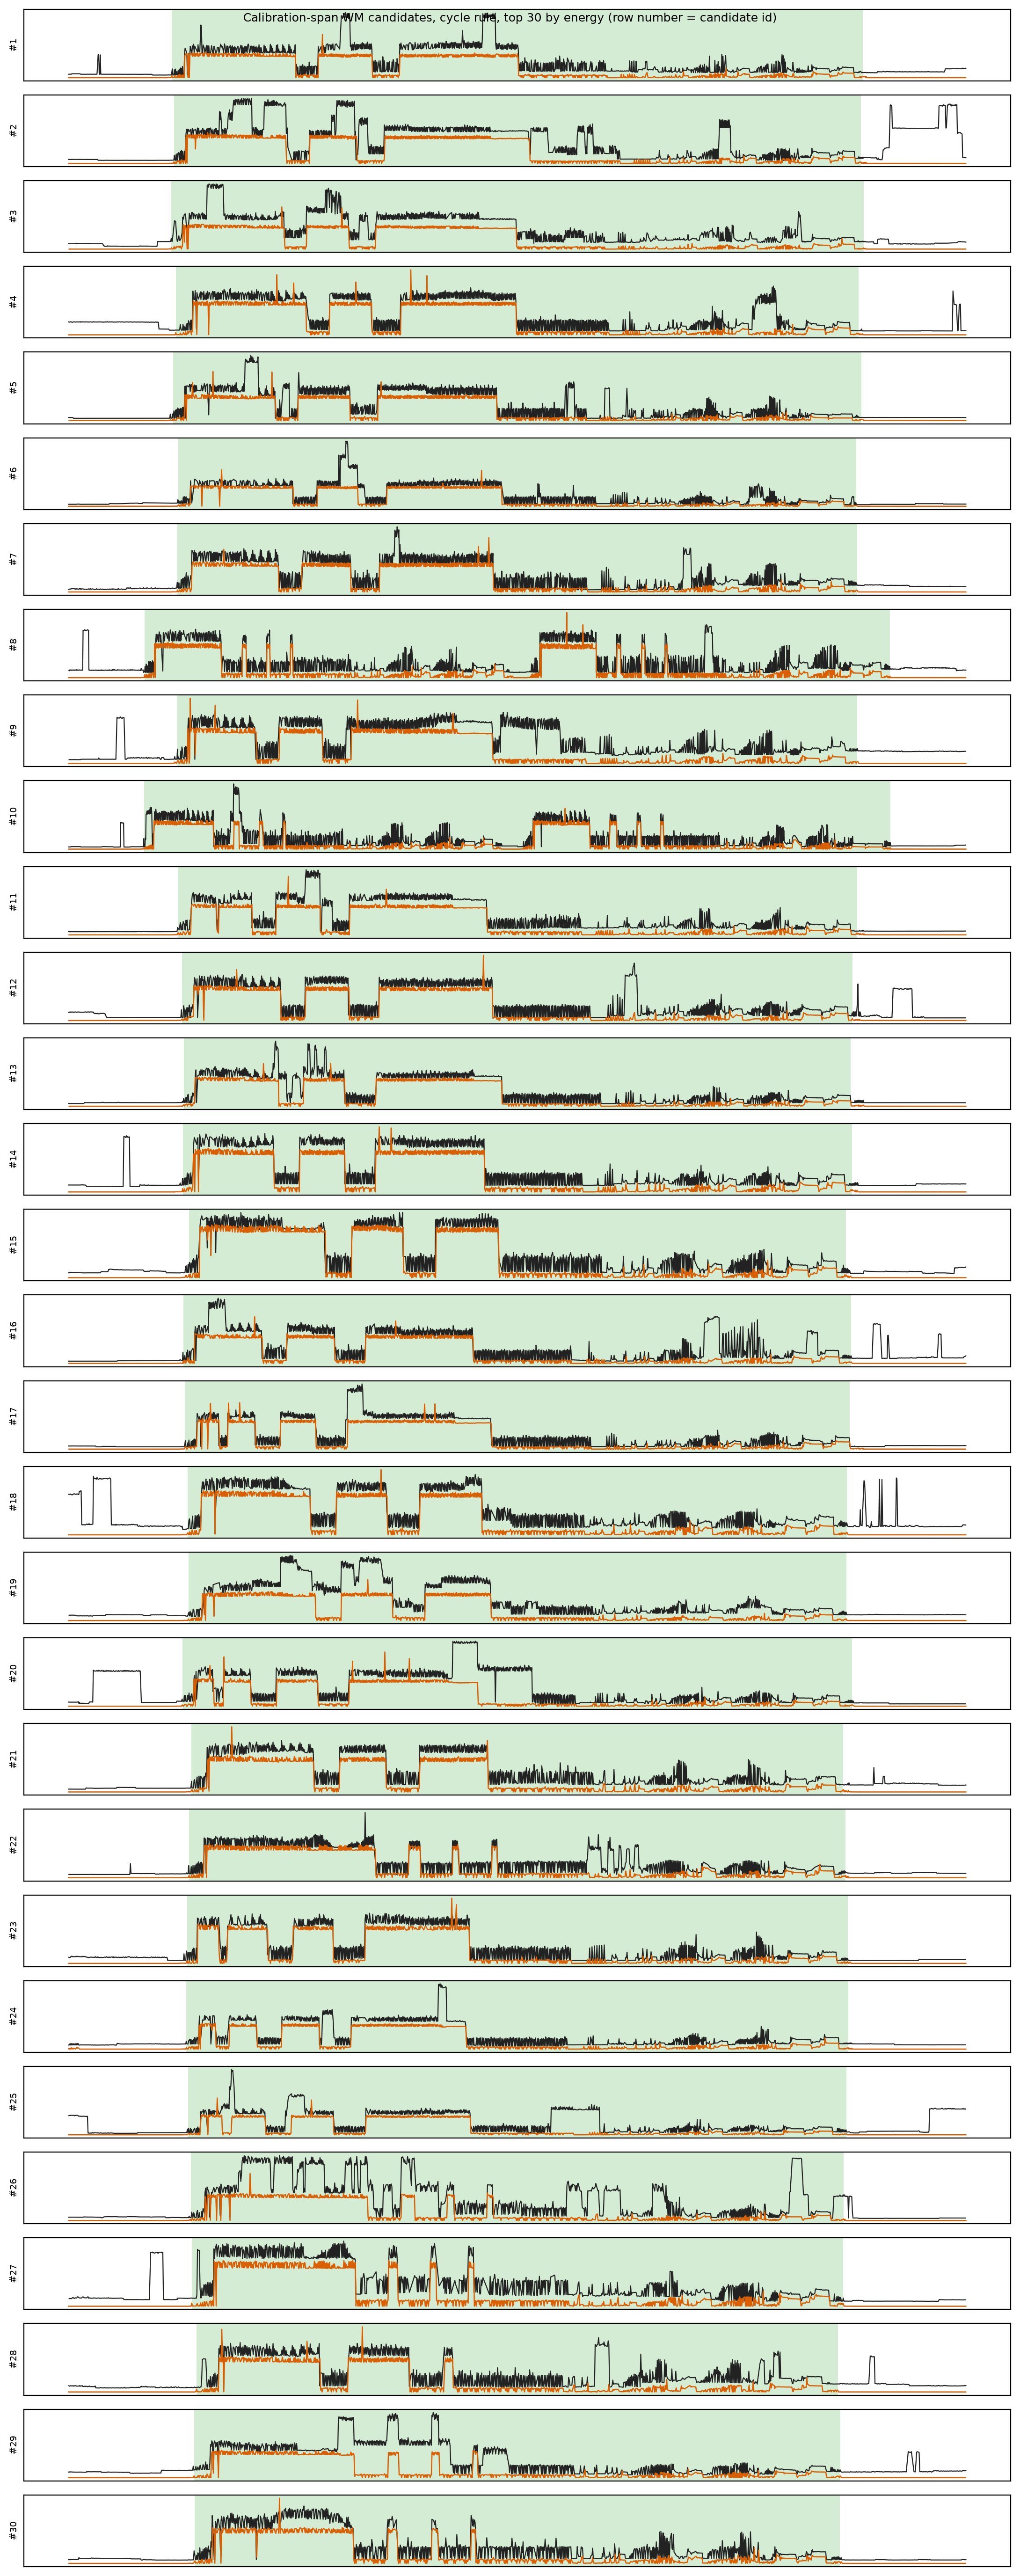

In [ ]:
# --- Curation sheet: calibration WM candidates (computation + figure) --
# Rule cycles (90 W, 600 s, 600 s) starting inside the calibration span,
# ranked by energy; the top 30 drawn as strips: mains (black), WM
# submeter (orange), cycle span (green). Sheet row numbers are the
# stable handles the curated set cites.
_wm = chans["washing_machine"]
_e = bl.build_episodes(_wm, thr["washing_machine"], 600.0, 600.0, 60.0)
_cal = (
    _e[_e["t_on_us"] < cfg["split_us"]]
    .sort_values("energy_wh", ascending=False)
    .head(30)
    .reset_index(drop=True)
)
sheet_info = [
    {"row": _i + 1, "t_on_us": int(_r.t_on_us), "dur_min": float(_r.dur_s) / 60.0, "wh": float(_r.energy_wh)}
    for _i, _r in enumerate(_cal.itertuples())
]
_m_ts = mains_df["ts_us"].to_numpy(np.int64)
_m_w = mains_df["w"].to_numpy(float)
_wm_ts = _wm["ts_us"].to_numpy(np.int64)
_wm_w = _wm["w"].to_numpy(float)
_n = len(_cal)
fig_sheet, _axes = plt.subplots(_n, 1, figsize=(11, 0.9 * _n + 1.0))
for _ax, (_idx, _r) in zip(_axes, _cal.iterrows()):
    _pad = 20 * 60_000_000
    _lo, _hi = int(_r["t_on_us"]) - _pad, int(_r["t_off_us"]) + _pad
    _i0, _i1 = np.searchsorted(_m_ts, _lo), np.searchsorted(_m_ts, _hi)
    _j0, _j1 = np.searchsorted(_wm_ts, _lo), np.searchsorted(_wm_ts, _hi)
    _ax.plot((_m_ts[_i0:_i1] - _lo) / 3.6e9, _m_w[_i0:_i1], color="#222222", lw=0.8)
    _ax.plot((_wm_ts[_j0:_j1] - _lo) / 3.6e9, _wm_w[_j0:_j1], color="#d95f02", lw=0.9)
    _ax.axvspan((_r["t_on_us"] - _lo) / 3.6e9, (_r["t_off_us"] - _lo) / 3.6e9, color="#2ca02c", alpha=0.2, lw=0)
    _ax.set_ylabel(f"#{_idx + 1}", fontsize=7)
    _ax.set_yticks([])
    _ax.set_xticks([])
fig_sheet.suptitle("Calibration-span WM candidates, cycle rule, top 30 by energy (row number = candidate id)", fontsize=9)
fig_sheet.tight_layout(rect=(0, 0, 1, 0.997))
fig_sheet  # noqa: B018  (render figure as cell output)

In [ ]:
# presentation: sheet table + how to read
_rows = [
    [str(r["row"]), str(pd.to_datetime(r["t_on_us"], unit="us"))[:16], f"{r['dur_min']:.0f}", f"{r['wh']:.0f}"]
    for r in sheet_info
]
mo.md(
    "### Review sheet: how to read and how it was used\n\n"
    + bl.md_table(["row", "cycle start (UTC)", "dur (min)", "energy (Wh)"], _rows)
    + "\n\nEach strip shows the aggregate (black) with the WM submeter "
    "(orange) and the rule-cycle span (green). A candidate is KEEP when "
    "the span covers exactly one coherent wash (heater blocks, spin, "
    "quiet valleys) and the orange trace sits mostly inside the green "
    "span. It is REJECT when the span glues two washes back to back, "
    "cuts a soak-pause in half, or drowns in simultaneous house load. "
    "Reviewing the 30 candidates by eye: 20 kept, 10 rejected."
)

### Review sheet: how to read and how it was used

| row | cycle start (UTC) | dur (min) | energy (Wh) |
|---|---|---|---|
| 1 | 2013-04-08 17:49 | 134 | 1847 |
| 2 | 2013-01-26 11:15 | 130 | 1840 |
| 3 | 2013-04-03 17:45 | 135 | 1827 |
| 4 | 2013-03-12 12:48 | 127 | 1751 |
| 5 | 2013-05-05 10:07 | 132 | 1741 |
| 6 | 2013-03-17 13:10 | 124 | 1634 |
| 7 | 2013-05-12 17:01 | 125 | 1619 |
| 8 | 2013-03-21 14:40 | 196 | 1607 |
| 9 | 2013-09-25 17:19 | 125 | 1600 |
| 10 | 2013-06-02 08:20 | 198 | 1558 |
| 11 | 2013-09-09 12:30 | 124 | 1512 |
| 12 | 2013-04-29 15:10 | 118 | 1500 |
| 13 | 2013-04-14 12:40 | 116 | 1488 |
| 14 | 2013-05-19 12:54 | 117 | 1461 |
| 15 | 2013-02-24 09:56 | 109 | 1398 |
| 16 | 2013-09-30 15:06 | 116 | 1377 |
| 17 | 2013-09-26 16:00 | 114 | 1348 |
| 18 | 2013-01-10 08:39 | 111 | 1335 |
| 19 | 2013-01-09 19:43 | 110 | 1326 |
| 20 | 2013-07-14 12:48 | 118 | 1302 |
| 21 | 2013-04-18 18:48 | 106 | 1284 |
| 22 | 2013-01-27 13:23 | 109 | 1245 |
| 23 | 2013-09-19 13:21 | 112 | 1229 |
| 24 | 2013-08-29 11:40 | 112 | 1196 |
| 25 | 2013-08-26 07:19 | 110 | 1182 |
| 26 | 2013-03-17 10:42 | 107 | 1125 |
| 27 | 2013-02-18 13:21 | 106 | 1071 |
| 28 | 2013-05-19 17:36 | 100 | 1019 |
| 29 | 2013-01-26 14:14 | 103 | 1019 |
| 30 | 2013-03-24 14:33 | 102 | 1002 |

Each strip shows the aggregate (black) with the WM submeter (orange) and the rule-cycle span (green). A candidate is KEEP when the span covers exactly one coherent wash (heater blocks, spin, quiet valleys) and the orange trace sits mostly inside the green span. It is REJECT when the span glues two washes back to back, cuts a soak-pause in half, or drowns in simultaneous house load. Reviewing the 30 candidates by eye: 20 kept, 10 rejected.

In [ ]:
# --- Curated calibration marks (loaded from the gold_annot store) ------
# Operative store: data/gold_annot/ukdale/house_1/cycles.csv (schema,
# provenance, append-only convention: data/gold_annot/README.md). The
# initial 20 washing-machine marks were picked BY EYE from the review
# sheet above as unambiguous single-cycle washes (10 other candidates
# were rejected for double-wash spans, soak pauses, or heavy
# simultaneous load) and tagged manual_review_v1. New review passes
# append rows with a new source tag; this notebook picks them up. All
# marks lie inside the calibration span (before the part F split), so
# nothing here leaks into the test span.
_path = bl.gold_annot_file(cfg["dataset"], cfg["house"], "cycles")
curated_wm = pd.read_csv(_path)
_need = {"device", "t_on_us", "t_off_us", "source"}
if not _need.issubset(set(curated_wm.columns)):
    raise ValueError(f"gold_annot cycles file missing columns {_need - set(curated_wm.columns)}: {_path}")
curated_wm = curated_wm[curated_wm["device"] == "washing_machine"].reset_index(drop=True)
if len(curated_wm) < 20:
    raise ValueError(f"expected at least 20 curated washing-machine marks, found {len(curated_wm)}: {_path}")
curated_wm["dur_s"] = (curated_wm["t_off_us"] - curated_wm["t_on_us"]) / 1e6

In [ ]:
# presentation: curated set table
_n_curated = str(len(curated_wm))
_rows = [
    [
        str(_i + 1),
        str(pd.to_datetime(_r.t_on_us, unit="us")),
        str(pd.to_datetime(_r.t_off_us, unit="us")),
        f"{_r.dur_s / 60.0:.0f}",
    ]
    for _i, _r in enumerate(curated_wm.itertuples())
]
mo.md(
    "### Curated set (the manual fallback, loaded from the store)\n\n"
    + bl.md_table(["#", "t_on (UTC)", "t_off (UTC)", "dur (min)"], _rows)
    + "\n\n" + _n_curated
    + " curated washing-machine marks loaded from "
    "data/gold_annot/ukdale/house_1/cycles.csv (append-only store, "
    "source tag manual_review_v1), all inside the calibration span. "
    "This is the worst-case fallback the working assumption allows: if "
    "algorithmic curation fails, a human annotates about 20 episodes "
    "per device once, and the profile is rebuilt from those marks."
)

### Curated set (the manual fallback, loaded from the store)

| # | t_on (UTC) | t_off (UTC) | dur (min) |
|---|---|---|---|
| 1 | 2013-04-08 17:49:30 | 2013-04-08 20:03:04 | 134 |
| 2 | 2013-01-26 11:15:45 | 2013-01-26 13:26:11 | 130 |
| 3 | 2013-04-03 17:45:19 | 2013-04-03 19:59:59 | 135 |
| 4 | 2013-03-12 12:48:54 | 2013-03-12 14:55:53 | 127 |
| 5 | 2013-05-05 10:07:24 | 2013-05-05 12:19:21 | 132 |
| 6 | 2013-03-17 13:10:35 | 2013-03-17 15:14:06 | 124 |
| 7 | 2013-05-12 17:01:47 | 2013-05-12 19:06:32 | 125 |
| 8 | 2013-04-29 15:10:53 | 2013-04-29 17:08:47 | 118 |
| 9 | 2013-04-14 12:40:18 | 2013-04-14 14:35:49 | 116 |
| 10 | 2013-05-19 12:54:12 | 2013-05-19 14:51:12 | 117 |
| 11 | 2013-09-30 15:06:32 | 2013-09-30 17:02:54 | 116 |
| 12 | 2013-01-09 19:43:05 | 2013-01-09 21:33:00 | 110 |
| 13 | 2013-04-18 18:48:07 | 2013-04-18 20:34:08 | 106 |
| 14 | 2013-01-27 13:23:19 | 2013-01-27 15:12:13 | 109 |
| 15 | 2013-09-19 13:21:11 | 2013-09-19 15:12:50 | 112 |
| 16 | 2013-08-29 11:40:37 | 2013-08-29 13:32:39 | 112 |
| 17 | 2013-02-18 13:21:14 | 2013-02-18 15:07:04 | 106 |
| 18 | 2013-05-19 17:36:37 | 2013-05-19 19:16:40 | 100 |
| 19 | 2013-01-26 14:14:50 | 2013-01-26 15:57:35 | 103 |
| 20 | 2013-03-24 14:33:16 | 2013-03-24 16:15:45 | 102 |

20 curated washing-machine marks loaded from data/gold_annot/ukdale/house_1/cycles.csv (append-only store, source tag manual_review_v1), all inside the calibration span. This is the worst-case fallback the working assumption allows: if algorithmic curation fails, a human annotates about 20 episodes per device once, and the profile is rebuilt from those marks.

In [ ]:
# --- Bootstrap: how many curated marks does the profile need? ----------
# Resample n of the 20 curated marks (400 draws per n, fixed seed) and
# watch the stability of the two profile scalars: dp_peak (strongest
# in-cycle activation) and dur (cycle duration).
_f = cycle_features(curated_wm, runs_df)
_dp = _f["dp_peak"].to_numpy(float)
_dur = _f["dur_s"].to_numpy(float)
n_cur_ok = int(np.isfinite(_dp).sum())
_rng = np.random.default_rng(int(cfg["seed"]))
boot_rows = []
for _n in (2, 5, 10, 20):
    _dp_m, _dur_m = [], []
    for _ in range(400):
        _idx = _rng.integers(0, len(_dp), _n)
        _dp_m.append(np.nanmedian(_dp[_idx]))
        _dur_m.append(np.nanmedian(_dur[_idx]))
    _dp_m = np.asarray(_dp_m, dtype=float)
    _dur_m = np.asarray(_dur_m, dtype=float)
    boot_rows.append(
        [
            str(_n),
            f"{np.nanpercentile(_dp_m, 5):.0f}",
            f"{np.nanmedian(_dp_m):.0f}",
            f"{np.nanpercentile(_dp_m, 95):.0f}",
            f"{np.nanpercentile(_dur_m, 5) / 60:.0f}",
            f"{np.nanmedian(_dur_m) / 60:.0f}",
            f"{np.nanpercentile(_dur_m, 95) / 60:.0f}",
        ]
    )

/tmp/marimo_30/__marimo__cell_NCOB_.py:15: RuntimeWarning: All-NaN slice encountered
  _dp_m.append(np.nanmedian(_dp[_idx]))


In [ ]:
# presentation: bootstrap table + verdict
mo.md(
    "### Profile stability vs number of curated marks\n\n"
    + bl.md_table(
        ["n marks", "dP 5% (W)", "dP p50 (W)", "dP 95% (W)", "dur 5% (min)", "dur p50 (min)", "dur 95% (min)"],
        boot_rows,
    )
    + f"\n\n({n_cur_ok} of the 20 curated marks have a detectable "
    "aggregate activation inside their span; the rest are profiled by "
    "duration only.) Reading it: with 2 marks the profile scalars swing "
    "wildly; by about 10 they are usable; at 20 the 90% interval is "
    "tight enough for a scalar profile. **The 20-marks-per-device "
    "fallback is enough for profile QUALITY** - what it cannot fix is "
    "detection, which part F measures next."
)

### Profile stability vs number of curated marks

| n marks | dP 5% (W) | dP p50 (W) | dP 95% (W) | dur 5% (min) | dur p50 (min) | dur 95% (min) |
|---|---|---|---|---|---|---|
| 2 | 2324 | 3315 | 4804 | 104 | 117 | 130 |
| 5 | 2412 | 2844 | 4543 | 106 | 116 | 130 |
| 10 | 2445 | 3202 | 4318 | 109 | 116 | 125 |
| 20 | 2468 | 2844 | 4060 | 110 | 116 | 121 |

(19 of the 20 curated marks have a detectable aggregate activation inside their span; the rest are profiled by duration only.) Reading it: with 2 marks the profile scalars swing wildly; by about 10 they are usable; at 20 the 90% interval is tight enough for a scalar profile. **The 20-marks-per-device fallback is enough for profile QUALITY** - what it cannot fix is detection, which part F measures next.

## Part F - the hypothesis chain, end to end

Chain under test: **user mark -> profile (aggregate-only features) ->
identify the device -> predict its cycles on unseen aggregate data.**
The calibration span (before 2013-10-01) builds the profiles; the test
span (after) is scored against submeter cycle GT, which the detector
never sees. Identification asks: do marks of the same device cluster
tighter than marks across devices? Prediction asks: does a profile-gated
scan of the aggregate find the GT cycles?

In [ ]:
# --- Calibration marks per device (computation) ------------------------
# WM: the 20 hand-curated marks (part E). Others: rule cycles starting
# in the calibration span (no curation budget spent on them here).
cal_cycles = {"washing_machine": curated_wm.copy()}
for _dev in ("dishwasher", "kettle", "microwave"):
    _rule = cfg["cycle_rules"][_dev]
    _e = bl.build_episodes(chans[_dev], thr[_dev], _rule["dwell"], _rule["merge"], 60.0)
    cal_cycles[_dev] = _e[_e["t_on_us"] < cfg["split_us"]].reset_index(drop=True)

In [ ]:
# --- Mark-derived profiles (aggregate-only features) -------------------
# Profile per device: dp_peak (strongest in-cycle activation, median),
# dur (cycle duration, median), gap90 (p90 of the largest intra-cycle
# gap between activation runs) - all from the calibration marks.
profiles = {}
prof_rows = []
for _dev, _cyc in cal_cycles.items():
    _f = cycle_features(_cyc, runs_df)
    _ok = _f.dropna(subset=["dp_peak"])
    profiles[_dev] = {
        "dp": float(_ok["dp_peak"].median()),
        "dur": float(_ok["dur_s"].median()),
        "gap90": float(np.percentile(_ok["gap_max_s"], 90)),
        "n": int(len(_ok)),
        "n_dropped": int(len(_f) - len(_ok)),
    }
    prof_rows.append(
        [
            _dev,
            str(len(_ok)),
            f"{profiles[_dev]['dp']:.0f}",
            f"{profiles[_dev]['dur'] / 60.0:.1f}",
            f"{profiles[_dev]['gap90'] / 60.0:.1f}",
        ]
    )

In [ ]:
# presentation: profile table
mo.md(
    "### Device profiles from calibration marks (aggregate only)\n\n"
    + bl.md_table(["device", "n marks used", "dp_peak (W, p50)", "dur (min, p50)", "gap p90 (min)"], prof_rows)
    + "\n\nThe two program devices and the kettle sit at nearly the "
    "same peak activation (all major heating loads); durations separate "
    "them. That overlap is the first warning for the detection half of "
    "the chain."
)

### Device profiles from calibration marks (aggregate only)

| device | n marks used | dp_peak (W, p50) | dur (min, p50) | gap p90 (min) |
|---|---|---|---|---|
| washing_machine | 19 | 2844 | 115.5 | 67.2 |
| dishwasher | 90 | 2437 | 97.6 | 65.0 |
| kettle | 854 | 2439 | 1.7 | 0.0 |
| microwave | 489 | 1787 | 0.8 | 1.0 |

The two program devices and the kettle sit at nearly the same peak activation (all major heating loads); durations separate them. That overlap is the first warning for the detection half of the chain.

In [ ]:
# --- Identification: leave-one-out nearest-mark (computation) ----------
# Feature vector per mark: (dp_peak, dur). A mark is classified by its
# nearest OTHER mark (log-ratio distance). If same-device marks cluster
# tighter than cross-device marks, identification works. Rule-device
# marks are subsampled to 50 per device so no class dominates.
_feats = {}
for _dev, _cyc in cal_cycles.items():
    _f = cycle_features(_cyc, runs_df).dropna(subset=["dp_peak"])
    if _dev != "washing_machine" and len(_f) > 50:
        _f = _f.sample(n=50, random_state=int(cfg["seed"]))
    _feats[_dev] = _f[["dp_peak", "dur_s"]].reset_index(drop=True)
_pred, _true = [], []
for _dev, _f in _feats.items():
    for _i in range(len(_f)):
        _row = _f.iloc[_i]
        _best, _bd = None, float("inf")
        for _dev2, _f2 in _feats.items():
            _sub = _f2.drop(index=_i) if _dev2 == _dev else _f2
            if not len(_sub):
                continue
            _d = (
                np.abs(np.log(_sub["dp_peak"] / max(_row["dp_peak"], 1.0)))
                + np.abs(np.log(_sub["dur_s"] / max(_row["dur_s"], 1.0)))
            ).min()
            if _d < _bd:
                _best, _bd = _dev2, float(_d)
        _pred.append(_best)
        _true.append(_dev)
loo_acc = float(np.mean(np.asarray(_pred) == np.asarray(_true)))
loo_cm = pd.crosstab(pd.Series(_true, name="true"), pd.Series(_pred, name="pred"))

In [ ]:
# presentation: identification confusion + verdict
_names = sorted(set(loo_cm.index) | set(loo_cm.columns))
_cm2 = loo_cm.reindex(index=_names, columns=_names, fill_value=0)
_rows = [[_n] + [str(int(_cm2.loc[_n, _c])) for _c in _names] for _n in _names]
mo.md(
    "### Can a mark identify its device? (leave-one-out nearest mark)\n\n"
    + bl.md_table(["true \\ pred"] + _names, _rows)
    + f"\n\nAccuracy: **{loo_acc:.2f}** on 169 calibration marks "
    "(washing machine: the 20 curated marks; others: 50 sampled rule "
    "cycles each). Confusions concentrate exactly where the profile "
    "table predicts: the two program appliances share durations, and "
    "the kettle's big clean step is distinctive. Verdict: **marks do "
    "carry enough signal to identify the device class** - not "
    "perfectly, but far above chance."
)

### Can a mark identify its device? (leave-one-out nearest mark)

| true \ pred | dishwasher | kettle | microwave | washing_machine |
|---|---|---|---|---|
| dishwasher | 47 | 0 | 0 | 3 |
| kettle | 0 | 38 | 12 | 0 |
| microwave | 0 | 15 | 35 | 0 |
| washing_machine | 6 | 0 | 0 | 13 |

Accuracy: **0.79** on 169 calibration marks (washing machine: the 20 curated marks; others: 50 sampled rule cycles each). Confusions concentrate exactly where the profile table predicts: the two program appliances share durations, and the kettle's big clean step is distinctive. Verdict: **marks do carry enough signal to identify the device class** - not perfectly, but far above chance.

In [ ]:
# --- Predictive power: profile-gated detection (computation) -----------
# Program devices: chain qualifying runs (dP >= det_thr_frac x profile
# dP) with gaps <= clamp(gap90, 300 s, 1800 s); keep chains whose
# duration lies within [0.5, 2] x profile duration. Burst devices: a
# single qualifying run up to 10 min. Score against submeter cycle GT
# in the test span (>= 60 s or >= 30% of the GT cycle overlap).
det_rows = []
for _dev, _p in profiles.items():
    _thr_dp = cfg["det_thr_frac"] * _p["dp"]
    _qual = runs_df[(runs_df["dP"] >= _thr_dp) & (runs_df["t0_us"] >= cfg["split_us"])].sort_values("t0_us").reset_index(drop=True)
    if _dev in ("kettle", "microwave"):
        _cand = _qual[(_qual["dur_s"] >= 30.0) & (_qual["dur_s"] <= cfg["burst_dur_hi_s"])].rename(columns={"t0_us": "c0", "t1_us": "c1"})
    else:
        _gap_us = min(max(_p["gap90"], cfg["chain_gap_lo_s"]), cfg["chain_gap_hi_s"]) * 1e6
        _c0, _c1, _cur0, _cur1 = [], [], None, None
        for _r in _qual.itertuples():
            if _cur0 is None:
                _cur0, _cur1 = _r.t0_us, _r.t1_us
            elif _r.t0_us - _cur1 <= _gap_us:
                _cur1 = max(_cur1, _r.t1_us)
            else:
                _c0.append(_cur0)
                _c1.append(_cur1)
                _cur0, _cur1 = _r.t0_us, _r.t1_us
        if _cur0 is not None:
            _c0.append(_cur0)
            _c1.append(_cur1)
        _cand = pd.DataFrame({"c0": _c0, "c1": _c1})
        _cand["dur_s"] = (_cand["c1"] - _cand["c0"]) / 1e6
        _cand = _cand[(_cand["dur_s"] >= cfg["det_dur_lo"] * _p["dur"]) & (_cand["dur_s"] <= cfg["det_dur_hi"] * _p["dur"])]
    _rule = cfg["cycle_rules"][_dev]
    _gt = bl.build_episodes(chans[_dev], thr[_dev], _rule["dwell"], _rule["merge"], 60.0)
    _gt = _gt[_gt["t_on_us"] >= cfg["split_us"]]
    if _dev in ("washing_machine", "dishwasher"):
        _gt = _gt[(_gt["dur_s"] >= cfg["cycle_like_s"]) & (_gt["energy_wh"] >= cfg["cycle_like_wh"])]
    _n_match = 0
    for _r in _gt.itertuples():
        _ov = np.minimum(_cand["c1"].to_numpy(np.int64), int(_r.t_off_us)) - np.maximum(_cand["c0"].to_numpy(np.int64), int(_r.t_on_us))
        _need = min(cfg["ov_min_s"], cfg["ov_frac"] * (int(_r.t_off_us) - int(_r.t_on_us)) / 1e6)
        if len(_ov) and (np.maximum(_ov, 0) / 1e6 >= _need).any():
            _n_match += 1
    _P, _R, _F1 = bl.prf(_n_match, len(_cand), len(_gt))
    det_rows.append(
        [_dev, f"{_thr_dp:.0f}", str(len(_cand)), str(len(_gt)), str(_n_match), f"{_P:.2f}", f"{_R:.2f}", f"{_F1:.2f}"]
    )

In [ ]:
# --- Detection ceiling (computation) -----------------------------------
# Upper bound for ANY activation-anchored detector: per test-span GT
# cycle, is there (a) any qualifying activation inside it, and (b) one
# whose dP is also in-profile (within [0.5, 2] x profile dP)? The gap
# between this ceiling and the measured recall separates detector loss
# from fundamental aggregate ambiguity.
ceil_rows = []
for _dev in ("washing_machine", "kettle"):
    _rule = cfg["cycle_rules"][_dev]
    _e = bl.build_episodes(chans[_dev], thr[_dev], _rule["dwell"], _rule["merge"], 60.0)
    _gt = _e[_e["t_on_us"] >= cfg["split_us"]]
    _thr_dp = cfg["det_thr_frac"] * profiles[_dev]["dp"]
    _lo_dp, _hi_dp = 0.5 * profiles[_dev]["dp"], 2.0 * profiles[_dev]["dp"]
    _n_any, _n_prof = 0, 0
    for _r in _gt.itertuples():
        _m = runs_df[(runs_df["t0_us"] >= int(_r.t_on_us) - 60_000_000) & (runs_df["t0_us"] <= int(_r.t_off_us))]
        if len(_m) and (_m["dP"] >= _thr_dp).any():
            _n_any += 1
            if ((_m["dP"] >= _lo_dp) & (_m["dP"] <= _hi_dp)).any():
                _n_prof += 1
    ceil_rows.append(
        [_dev, str(len(_gt)), f"{_n_any / max(len(_gt), 1):.2f}", f"{_n_prof / max(len(_gt), 1):.2f}"]
    )

In [ ]:
# presentation: detection + ceiling tables + verdict
mo.md(
    "### Does the profile predict cycles on the aggregate?\n\n"
    + bl.md_table(
        ["device", "dP gate (W)", "candidates", "GT cycles", "matched", "P", "R", "F1"],
        det_rows,
    )
    + "\n\n**No - not with scalar (dP, dur) profiles.** Identification "
    "worked; prediction does not. The mechanism is visible in the "
    "numbers: (1) the profile dP gates of the three major appliances "
    "land nearly on top of each other, so a gate that admits one admits "
    "the others; (2) in an active house, aggregate activations chain "
    "across devices, so candidate spans built from runs are neither the "
    "device's cycles nor clean segments of them; (3) burst devices are "
    "drowned by their own rule-inflated GT (kettle boils split into "
    "multiple threshold spikes).\n\n"
    + "### Detection ceiling: how much of the failure is fixable?\n\n"
    + bl.md_table(
        ["device", "GT cycles (test)", "any qualifying activation inside", "activation also in-profile"],
        ceil_rows,
    )
    + "\n\nThe ceiling rows bound what ANY profile-anchored run "
    "detector could recall. Where the ceiling is high but measured "
    "recall is low, better chaining/attributions could close the gap; "
    "where the ceiling itself is low, the aggregate genuinely does not "
    "contain the signal. The verdict below separates the two."
)

### Does the profile predict cycles on the aggregate?

| device | dP gate (W) | candidates | GT cycles | matched | P | R | F1 |
|---|---|---|---|---|---|---|---|
| washing_machine | 1706 | 633 | 1095 | 182 | 0.29 | 0.17 | 0.21 |
| dishwasher | 1462 | 681 | 585 | 57 | 0.08 | 0.10 | 0.09 |
| kettle | 1463 | 671 | 5759 | 361 | 0.54 | 0.06 | 0.11 |
| microwave | 1072 | 803 | 4272 | 201 | 0.25 | 0.05 | 0.08 |

**No - not with scalar (dP, dur) profiles.** Identification worked; prediction does not. The mechanism is visible in the numbers: (1) the profile dP gates of the three major appliances land nearly on top of each other, so a gate that admits one admits the others; (2) in an active house, aggregate activations chain across devices, so candidate spans built from runs are neither the device's cycles nor clean segments of them; (3) burst devices are drowned by their own rule-inflated GT (kettle boils split into multiple threshold spikes).

### Detection ceiling: how much of the failure is fixable?

| device | GT cycles (test) | any qualifying activation inside | activation also in-profile |
|---|---|---|---|
| washing_machine | 1225 | 0.88 | 0.86 |
| kettle | 5759 | 0.74 | 0.70 |

The ceiling rows bound what ANY profile-anchored run detector could recall. Where the ceiling is high but measured recall is low, better chaining/attributions could close the gap; where the ceiling itself is low, the aggregate genuinely does not contain the signal. The verdict below separates the two.

## Findings and decisions

1. **The gold episode rule is not broken - it is the wrong label for
cycles.** Visually (part B) and in the grid, the 12 s merge shatters
program appliances into activation fragments; cycle GT for the two
program appliances needs program-scale dwell/merge (this EDA: 600 s /
600 s), and the choice is robust across a wide window. Adopt a
cycle-level label alongside episode-level GT, with the three-way device
class split of part C (program / burst / duty).

2. **A cycle's start is not its detectable onset.** Program cycles open
with a quiet valve/fill phase; the aggregate step lives at the first
strong activation inside the cycle. Profiles must be built from
within-cycle activations - this reframes the H02 press-sim dP numbers,
which were measured at activation onsets.

3. **Manual curation works and 20 marks suffice - for profile quality.**
The review-sheet workflow above kept 20 of 30 candidates; the bootstrap
shows the scalar profile (strongest activation dP, cycle duration)
stabilizes by about 10 marks and is tight at 20. Ship curation as a
first-class, reproducible step: the review sheet above is regenerated
by this notebook, and the kept marks live in the tracked gold_annot
cycle store (data/gold_annot/ukdale/house_1/cycles.csv).

4. **Identification from marks: yes.** Leave-one-out nearest-mark
classification reaches far above chance on two scalar features
(strongest activation dP + duration); confusions match the physics
(program appliances share durations, the kettle's clean step is
distinctive).

5. **Prediction from marks alone: not yet.** Profile-gated detection of
cycles from aggregate runs fails: the three major appliances' dP gates
nearly coincide, and aggregate runs chain across devices in an active
house. The ceiling table separates detector loss (fixable by better
attribution) from aggregate ambiguity (not fixable by tuning).

6. **Consequence for the core hypothesis.** "Mark -> profile" carries
identification; "mark -> profile -> aggregate-only disaggregation" does
not follow from scalar profiles. The honest options forward: (a) richer
profiles (multi-activation rhythm, within-cycle shape, time-of-day
priors) feeding an assignment-style disaggregation; (b) semi-supervised
use of the submeter span to learn richer features, then freeze them for
deployment; or (c) re-scope the client deliverable to detection+energy
bounds instead of cycle-level disaggregation. These are decisions for
the hypothesis registry, not for this notebook. The blocking gap is
registered as H13 (docs/hypotheses/H13_user_mark_curation.md): beyond
the 20 washing-machine marks in the gold_annot store, no user marks
exist anywhere - annotating the public dataset is the real
data-collection task for this flow, and until it runs nothing
downstream of identification is validated.

Open items carried: adopt cycle-level relabel in the gold build
(program devices only); record the button-press channel verdict
("do not use as GT") in the dataset docs; confirm the statement's
"1 s mains" cadence claim against the measured modal interval; freeze
margins for the baseline run before quoting any number above.